In [39]:
!pip3 install pandas numpy matplotlib seaborn

In [40]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
bet = 1
count = 0 
price = 0
count_heads = 0
count_tails = 0
bet_dict = []
itr = 1000
no_of_flips = 100000

### 0 -> Tail
### 1 -> Head

In [60]:
for i in range(no_of_flips):
    flip = random.choice(['heads', 'tails'])
    if flip == 'heads':
        count_heads += 1
        price += bet
    else:
        count_tails += 1
        price -= bet
    count += 1
    bet_dict.append(price)

In [61]:
print(f"Total flips: {count}")
print(f"Heads: {count_heads}, Tails: {count_tails}")
print(f"Final price: {price}")

Total flips: 100000
Heads: 50038, Tails: 49962
Final price: 76


In [44]:
bet_df = pd.DataFrame(bet_dict, columns=['Price'])

In [66]:
bet_df.describe()

,Price
count,100000.00000
mean,166.82886
std,67.61563
min,-35.00000
25%,136.00000
50%,175.00000
75%,216.00000
max,324.00000


In [64]:
bet_df[bet_df['Price'] == bet_df['Price'].min()]

,Price
98,-35
100,-35
102,-35


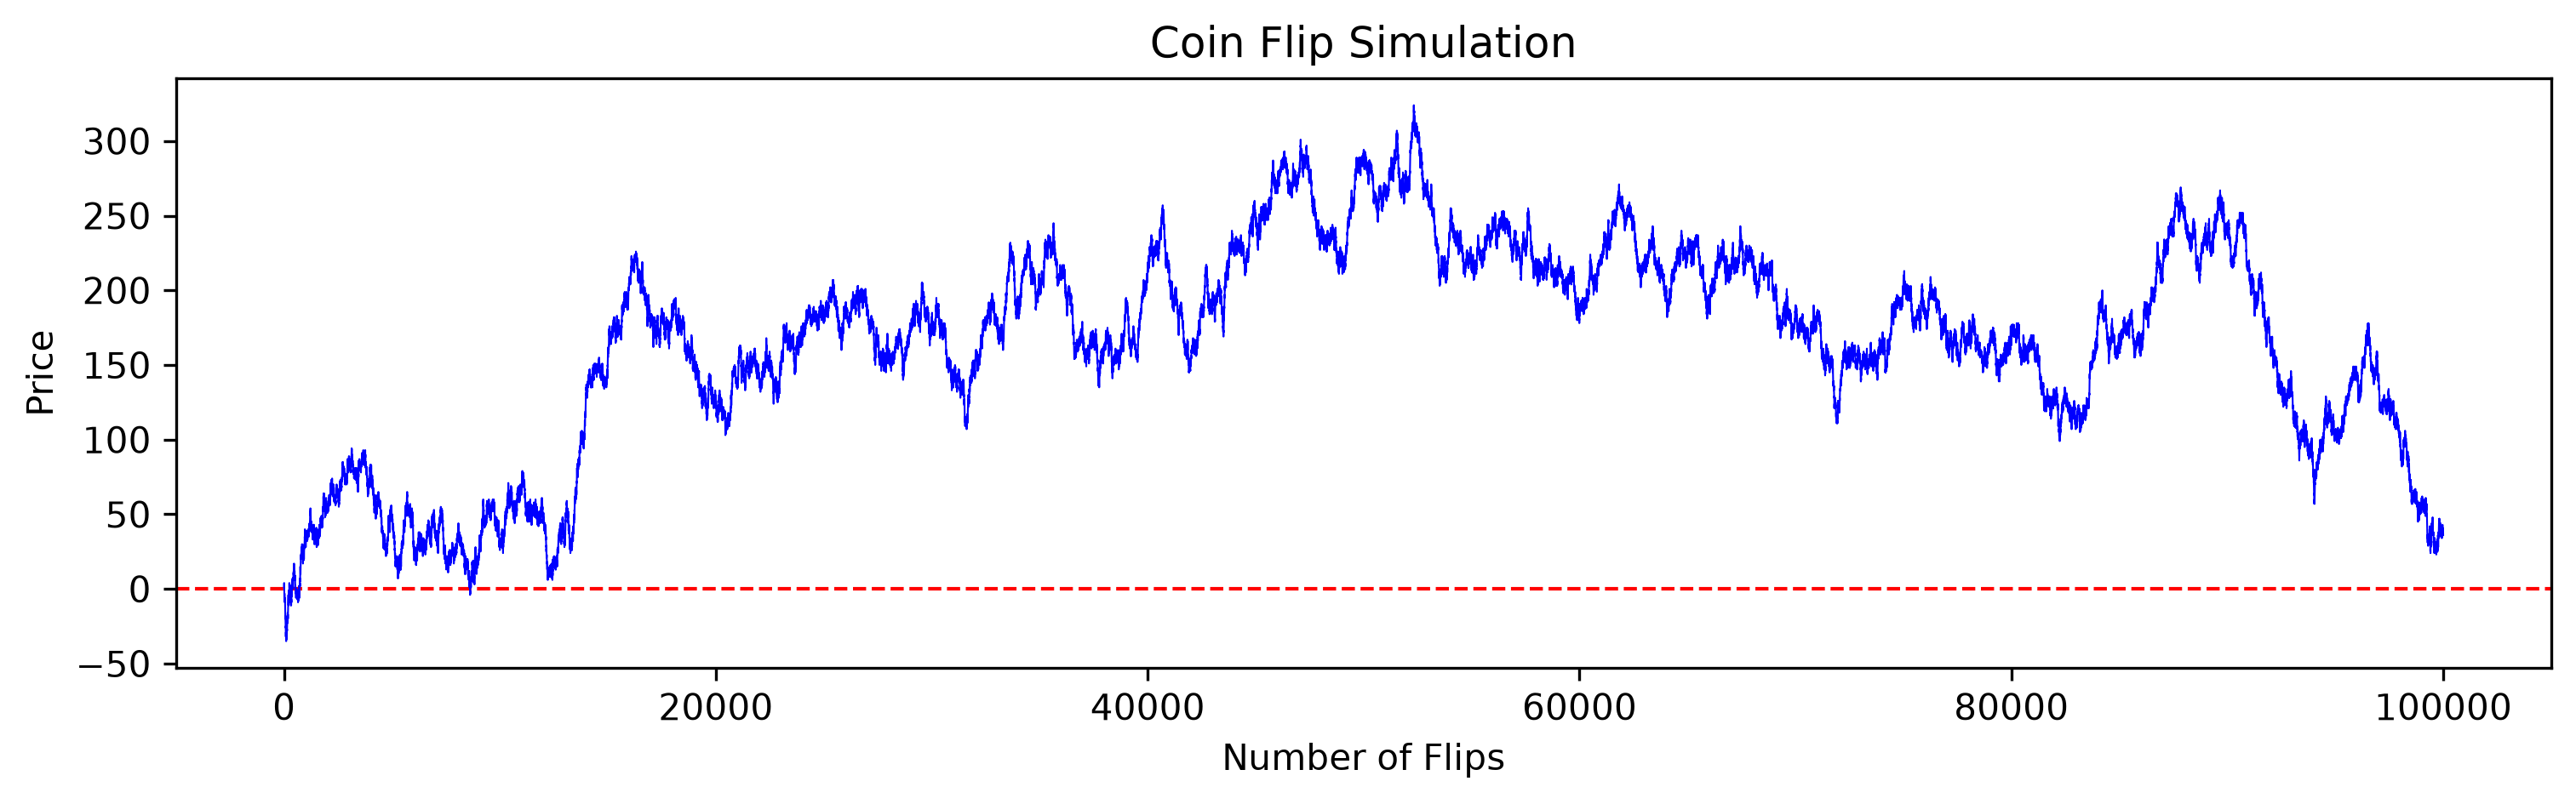

In [65]:
plt.figure(figsize=(12, 3), dpi=300)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.plot(bet_df['Price'], color='blue', linewidth=0.5)
plt.title('Coin Flip Simulation')
plt.xlabel('Number of Flips')
plt.ylabel('Price')
plt.show()

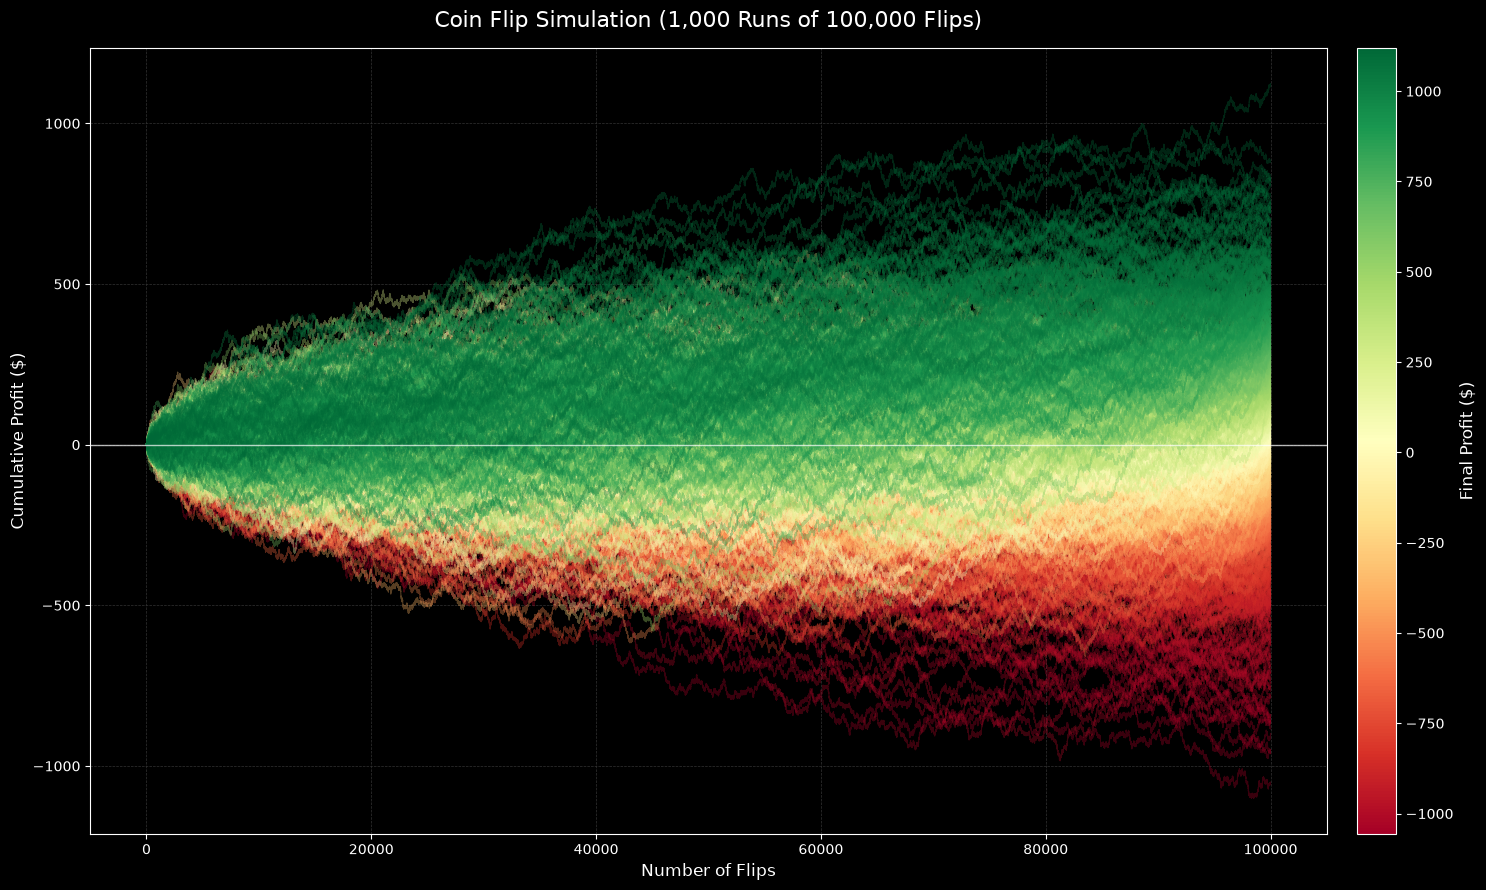

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Simulation Parameters ---
no_of_flips = 100000
itr = 1000
bet = 1

# --- 2. Vectorized Coin Flip Simulation (NumPy) ---
# Generate random outcomes: +1 for Heads (profit), -1 for Tails (loss)
# Shape: (no_of_flips, itr) -> 100,000 steps across 1,000 runs
flips = np.random.choice([bet, -bet], size=(no_of_flips, itr))

# Calculate cumulative profit over time for each of the 1,000 runs
cumulative_profit = np.cumsum(flips, axis=0)

# --- 3. Sorting Runs for Color Gradient ---
# Get final profit for each of the 1,000 iterations
final_profits = cumulative_profit[-1, :]

# Sort the iteration indices from lowest final profit (worst) to highest (best)
sorted_indices = np.argsort(final_profits)

# --- 4. Plotting Settings (Black Background & Gradient) ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 9), facecolor='black')
ax.set_facecolor('black')

# Get the Red-to-Green Colormap (Updated for Matplotlib 3.7+)
cmap = plt.colormaps['RdYlGn']

# Plot all 1,000 runs
for rank, sim_idx in enumerate(sorted_indices):
    # Normalized rank (0.0 = worst/red, 1.0 = best/green)
    color_val = rank / (itr - 1)
    
    # Plot each line with slight transparency (alpha)
    ax.plot(
        cumulative_profit[:, sim_idx], 
        color=cmap(color_val), 
        alpha=0.35, 
        linewidth=0.8
    )

# --- 5. Chart Formatting ---
ax.set_title(f"Coin Flip Simulation ({itr:,} Runs of {no_of_flips:,} Flips)", fontsize=16, color='white', pad=15)
ax.set_xlabel("Number of Flips", fontsize=12, color='white')
ax.set_ylabel("Cumulative Profit ($)", fontsize=12, color='white')

# Gridlines and Spines
ax.grid(True, color='#333333', linestyle='--', linewidth=0.5)
ax.axhline(0, color='white', linestyle='-', linewidth=1, alpha=0.7) # Zero line

# Add Colorbar Legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=final_profits.min(), vmax=final_profits.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Final Profit ($)", color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax, 'yticklabels'), color='white')

plt.tight_layout()
plt.show()

In [93]:
print(f"Max profit: {final_profits.max()}")
print(f"Max loss: {final_profits.min()}")
print(f"Net profit: {final_profits.sum()}")
print(f"Mean profit: {final_profits.mean()}")
print(f"Median profit: {np.median(final_profits)}")
print(f"Standard Deviation of profits: {np.std(final_profits):.2f}")

print(f"Number of total heads across all iterations: {flips[flips == bet].sum() // bet}")
print(f"Number of total tails across all iterations: {flips[flips == -bet].sum() // (-bet)}")

print(f"No of iterations greater than 0: {(final_profits > 0).sum()}")
print(f"No of iterations less than 0: {(final_profits < 0).sum()}")
print(f"No of iterations equal to 0: {(final_profits == 0).sum()}")

Max profit: 1120
Max loss: -1056
Net profit: 11828
Mean profit: 11.828
Median profit: 22.0
Standard Deviation of profits: 323.28
Number of total heads across all iterations: 50005914
Number of total tails across all iterations: 49994086
No of iterations greater than 0: 531
No of iterations less than 0: 466
No of iterations equal to 0: 3


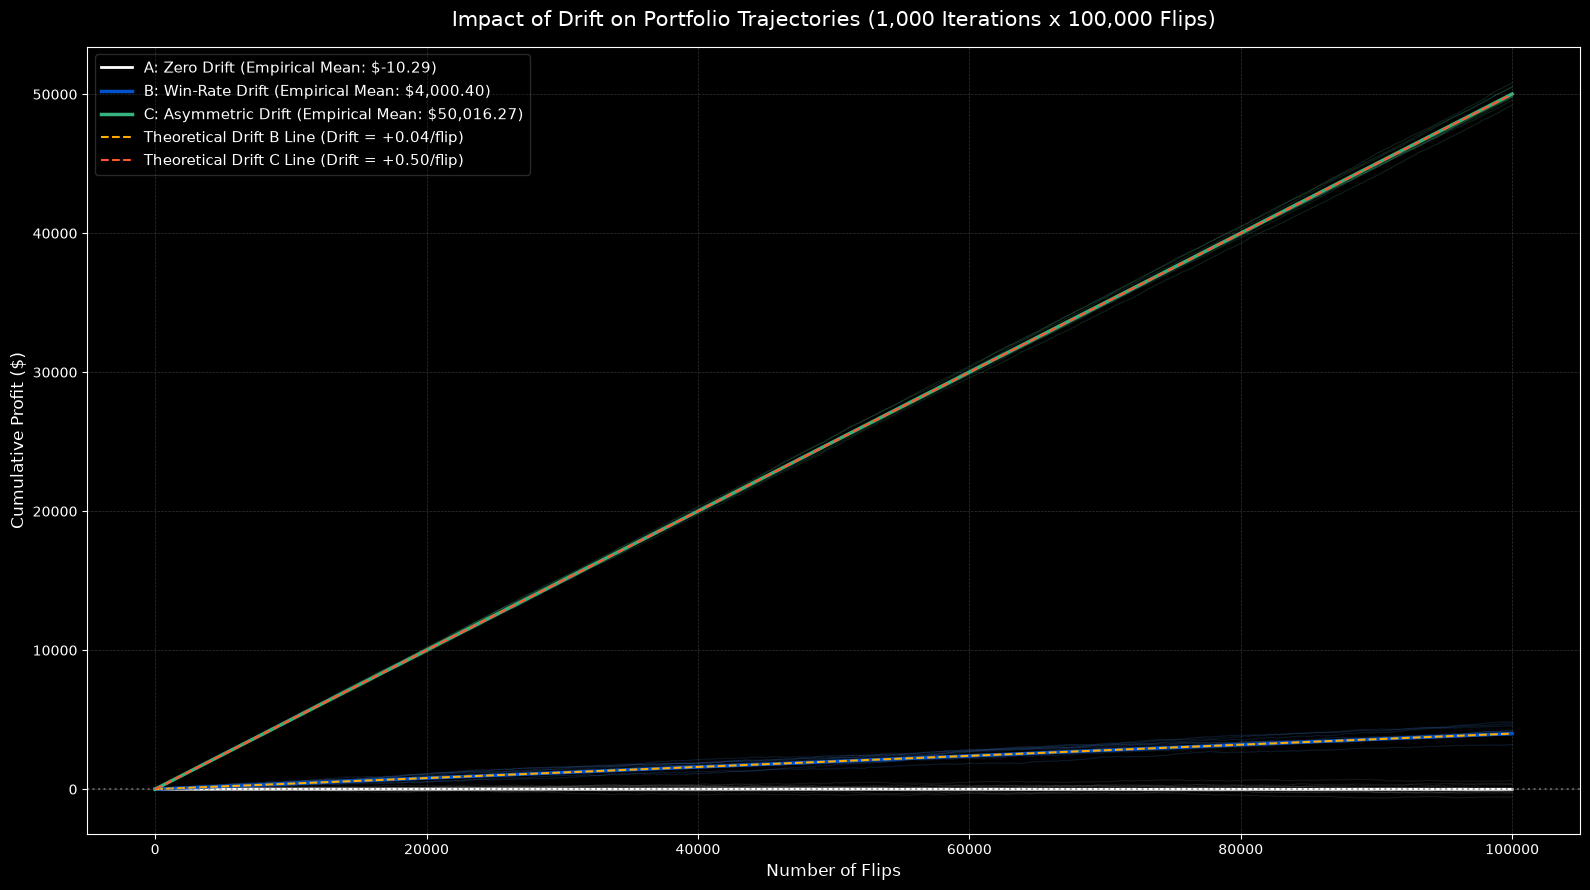

--- FINAL RESULTS AT 100,000 FLIPS ---
Scenario A (Zero Drift):       Expected = $0.00 | Actual Mean = $-10.29
Scenario B (Win-Rate Drift):   Expected = $4,000.00 | Actual Mean = $4,000.40
Scenario C (Asymmetric Drift): Expected = $50,000.00 | Actual Mean = $50,016.27


In [99]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Simulation Parameters ---
no_of_flips = 100000
itr = 1000

# --- 2. Scenario Definitions ---
# Scenario A: Zero Drift (p = 0.50, +1 / -1)
p_A = 0.50
reward_A, risk_A = 1.0, 1.0
drift_A = (p_A * reward_A) - ((1 - p_A) * risk_A) # Drift = 0.00

# Scenario B: Probability-Driven Drift (p = 0.52, +1 / -1)
p_B = 0.52
reward_B, risk_B = 1.0, 1.0
drift_B = (p_B * reward_B) - ((1 - p_B) * risk_B) # Drift = +0.04

# Scenario C: Asymmetric Payout Drift (p = 0.50, +1.50 / -0.50)
p_C = 0.50
reward_C, risk_C = 1.50, 0.50
drift_C = (p_C * reward_C) - ((1 - p_C) * risk_C) # Drift = +0.50

# --- 3. Vectorized Simulations ---
np.random.seed(42) # For reproducible random results

# Generate Bernoulli outcomes (1 = Heads, 0 = Tails)
flips_A = np.random.binomial(1, p_A, size=(no_of_flips, itr))
flips_B = np.random.binomial(1, p_B, size=(no_of_flips, itr))
flips_C = np.random.binomial(1, p_C, size=(no_of_flips, itr))

# Convert outcomes into payoffs
payoffs_A = np.where(flips_A == 1, reward_A, -risk_A)
payoffs_B = np.where(flips_B == 1, reward_B, -risk_B)
payoffs_C = np.where(flips_C == 1, reward_C, -risk_C)

# Calculate cumulative profit pathways
cum_A = np.cumsum(payoffs_A, axis=0)
cum_B = np.cumsum(payoffs_B, axis=0)
cum_C = np.cumsum(payoffs_C, axis=0)

# Calculate average equity curves across all 1,000 iterations
mean_A = np.mean(cum_A, axis=1)
mean_B = np.mean(cum_B, axis=1)
mean_C = np.mean(cum_C, axis=1)

# Theoretical Drift Lines
flips_axis = np.arange(1, no_of_flips + 1)
theoretical_A = flips_axis * drift_A
theoretical_B = flips_axis * drift_B
theoretical_C = flips_axis * drift_C

# --- 4. Plotting Results ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 9), facecolor='black')
ax.set_facecolor('black')

# Plot sample pathways (10 sample trajectories per scenario for visual clarity)
for i in range(10):
    ax.plot(cum_A[:, i], color='#888888', alpha=0.15, linewidth=0.8)
    ax.plot(cum_B[:, i], color='#4C9AFF', alpha=0.15, linewidth=0.8)
    ax.plot(cum_C[:, i], color='#57D9A3', alpha=0.15, linewidth=0.8)

# Plot Mean Empirical Equity Curves across 1,000 runs
ax.plot(mean_A, color='white', linewidth=2, label=f'A: Zero Drift (Empirical Mean: ${mean_A[-1]:,.2f})')
ax.plot(mean_B, color='#0052CC', linewidth=2.5, label=f'B: Win-Rate Drift (Empirical Mean: ${mean_B[-1]:,.2f})')
ax.plot(mean_C, color='#36B37E', linewidth=2.5, label=f'C: Asymmetric Drift (Empirical Mean: ${mean_C[-1]:,.2f})')

# Plot Theoretical Expected Drift Slopes
ax.plot(theoretical_B, color='#FFAB00', linestyle='--', linewidth=1.5, label=f'Theoretical Drift B Line (Drift = {drift_B:+.2f}/flip)')
ax.plot(theoretical_C, color='#FF5630', linestyle='--', linewidth=1.5, label=f'Theoretical Drift C Line (Drift = {drift_C:+.2f}/flip)')

# Chart Formatting
ax.set_title("Impact of Drift on Portfolio Trajectories (1,000 Iterations x 100,000 Flips)", fontsize=15, pad=15)
ax.set_xlabel("Number of Flips", fontsize=12)
ax.set_ylabel("Cumulative Profit ($)", fontsize=12)
ax.axhline(0, color='gray', linestyle=':', alpha=0.7)
ax.grid(True, color='#333333', linestyle='--', linewidth=0.5)

ax.legend(loc='upper left', fontsize=11, framealpha=0.2)
plt.tight_layout()
plt.show()

# --- 5. Terminal Output Stats ---
print("--- FINAL RESULTS AT 100,000 FLIPS ---")
print(f"Scenario A (Zero Drift):       Expected = ${theoretical_A[-1]:,.2f} | Actual Mean = ${mean_A[-1]:,.2f}")
print(f"Scenario B (Win-Rate Drift):   Expected = ${theoretical_B[-1]:,.2f} | Actual Mean = ${mean_B[-1]:,.2f}")
print(f"Scenario C (Asymmetric Drift): Expected = ${theoretical_C[-1]:,.2f} | Actual Mean = ${mean_C[-1]:,.2f}")

In [100]:
print("Scenario A")
print(f"Max profit: {cum_A.max()}, Max loss: {cum_A.min()}, Mean profit: {mean_A[-1]:.2f}, Median profit: {np.median(cum_A[-1, :]):.2f}, Std Dev: {np.std(cum_A[-1, :]):.2f}")
print(f"Total Heads: {np.sum(flips_A)}, Total Tails: {no_of_flips * itr - np.sum(flips_A)}")
print(f"No of iterations greater than 0: {(cum_A[-1, :] > 0).sum()}")
print(f"No of iterations less than 0: {(cum_A[-1, :] < 0).sum()}")
print(f"No of iterations equal to 0: {(cum_A[-1, :] == 0).sum()}")

print("Scenario B")
print(f"Max profit: {cum_B.max()}, Max loss: {cum_B.min()}, Mean profit: {mean_B[-1]:.2f}, Median profit: {np.median(cum_B[-1, :]):.2f}, Std Dev: {np.std(cum_B[-1, :]):.2f}")
print(f"Total Heads: {np.sum(flips_B)}, Total Tails: {no_of_flips * itr - np.sum(flips_B)}")
print(f"No of iterations greater than 0: {(cum_B[-1, :] > 0).sum()}")
print(f"No of iterations less than 0: {(cum_B[-1, :] < 0).sum()}")
print(f"No of iterations equal to 0: {(cum_B[-1, :] == 0).sum()}")

print("Scenario C")
print(f"Max profit: {cum_C.max()}, Max loss: {cum_C.min()}, Mean profit: {mean_C[-1]:.2f}, Median profit: {np.median(cum_C[-1, :]):.2f}, Std Dev: {np.std(cum_C[-1, :]):.2f}")
print(f"Total Heads: {np.sum(flips_C)}, Total Tails: {no_of_flips * itr - np.sum(flips_C)}")
print(f"No of iterations greater than 0: {(cum_C[-1, :] > 0).sum()}")
print(f"No of iterations less than 0: {(cum_C[-1, :] < 0).sum()}")
print(f"No of iterations equal to 0: {(cum_C[-1, :] == 0).sum()}")

Scenario A
Max profit: 1064.0, Max loss: -1083.0, Mean profit: -10.29, Median profit: -18.00, Std Dev: 322.00
Total Heads: 49994856, Total Tails: 50005144
No of iterations greater than 0: 481
No of iterations less than 0: 517
No of iterations equal to 0: 2
Scenario B
Max profit: 5027.0, Max loss: -83.0, Mean profit: 4000.40, Median profit: 4000.00, Std Dev: 315.94
Total Heads: 52000200, Total Tails: 47999800
No of iterations greater than 0: 1000
No of iterations less than 0: 0
No of iterations equal to 0: 0
Scenario C
Max profit: 51126.0, Max loss: -5.0, Mean profit: 50016.27, Median profit: 50019.00, Std Dev: 320.40
Total Heads: 50008133, Total Tails: 49991867
No of iterations greater than 0: 1000
No of iterations less than 0: 0
No of iterations equal to 0: 0
